# Bayesian Search Algorithm

Use bayesian search based on the paper: "Bayesian-Based Search Decision Framework and Search Strategy Analysis in Probabilistic Search"

link: https://onlinelibrary.wiley.com/doi/full/10.1155/2020/8865381

In [131]:
# Import necessary libraries
import networkx as nx
import random
import re
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from collections import defaultdict

In [3]:
# Constants
map_graph_path = "../graphs/original/final_graph.graphml" # .graphml file path
start_node = "n138"   # Start position (node)
target_node = "n515" # target's (ring) position (node)

p_tp = 0.8  # P(true positive)
p_fp = 0.2  # P(false positive)
p_tn = 0.9 # P(true negative)
p_fn = 0.1  # P(false negative)
B_lower = 0  # Lower boundary for maximum belief
B_upper = 1   # Upper boundary for maximum belief
max_steps = 213  # Maximum number of steps

# May I say "Fuck this paper's notations. What the fuck do you mean by 3 same equations having 3 distinct values??? What the hell is this level of inconsistency in naming variables???."

In [4]:
# Generic helper functions

# Display graph information
def display_graph_information(graph):
    # Print nodes data
    for node, data in graph.nodes(data=True):
        print(f"Node: {node}, Attributes: {data}")

    # Print edges data
    for u, v, data in graph.edges(data=True):
        print(f"Edge: ({u}, {v}), Attributes: {data}")

    print("Number of Nodes:", len(graph.nodes()))
    print("Number of Edges:", len(graph.edges()))

def add_edges_weight(graph):
    for u, v, data in graph.edges(data=True):
        data['weight'] = 1.0  # Assign a weight of 1 to each edge

In [5]:
# Set target (ring) position (node)
def set_target_node(graph, target_node_id):
    nx.set_node_attributes(graph, {target_node_id: {"target": True}})

In [1]:
import networkx as nx

def _as_float(x):
    try:
        return float(x)
    except Exception:
        return None

def apply_total_weight_from_graph_attrs(
    G: nx.Graph,
    total_keys=("d_wtot", "d_weight"),
    fallback_sum_keys=("d_wtime", "d_wsafety"),
    default_weight=1.0,
    verbose=True,
):
    """
    Ensure every edge has a numeric 'weight' taken from existing GraphML attributes.
    Priority:
        1) first found in total_keys
        2) sum of fallback_sum_keys (if both present and numeric)
        3) default_weight
    Works with Graph/DiGraph/Multi(Di)Graph.
    """
    set_count, fallback_count, default_count = 0, 0, 0

    if G.is_multigraph():
        edge_iter = G.edges(keys=True, data=True)
    else:
        edge_iter = G.edges(data=True)

    for e in edge_iter:
        # Unpack (u,v,data) or (u,v,k,data)
        if G.is_multigraph():
            u, v, k, data = e
        else:
            u, v, data = e

        # 1) Try total_keys
        chosen = None
        for k_attr in total_keys:
            if k_attr in data:
                val = _as_float(data[k_attr])
                if val is not None:
                    chosen = val
                    break

        # 2) Try fallback sum (only if needed)
        if chosen is None and fallback_sum_keys:
            vals = []
            ok = True
            for k_attr in fallback_sum_keys:
                if k_attr not in data:
                    ok = False
                    break
                vnum = _as_float(data[k_attr])
                if vnum is None:
                    ok = False
                    break
                vals.append(vnum)
            if ok and len(vals) == len(fallback_sum_keys):
                chosen = sum(vals)
                fallback_count += 1

        # 3) Default if still None
        if chosen is None:
            chosen = default_weight
            default_count += 1
        else:
            set_count += 1

        data["weight"] = chosen  # <- what Dijkstra/A* will use

    if verbose:
        print(f"[weight-mapper] set from totals: {set_count}, "
              f"fallback sums: {fallback_count}, defaults: {default_count}")

    return G


def load_graph_with_total_weight(
    graphml_path: str,
    total_keys=("d_wtot", "d_weight"),
    fallback_sum_keys=("d_wtime", "d_wsafety"),
    default_weight=1.0,
    directed=True,
    verbose=True,
):
    """
    Read a yEd GraphML and set 'weight' on edges based on stored totals.
    """
    # yEd often exports directed graphs; keep that unless you know yours is undirected.
    G = nx.read_graphml(graphml_path)
    # NetworkX may load as MultiDiGraph/DiGraph automatically; no need to convert.

    apply_total_weight_from_graph_attrs(
        G,
        total_keys=total_keys,
        fallback_sum_keys=fallback_sum_keys,
        default_weight=default_weight,
        verbose=verbose,
    )
    return G


In [218]:
# Bayesian search for incomplete information sensor

# Create an initial belief map
def initialize_belief_map(graph, choice, suspected_nodes=[]):
    """
        Choice:
            0: Uniform Belief Map
            1: Randomized Belief Map
            2: Peak (require suspected_node)
            3: Normal Distribution Map (require suspected_node)
    """
    num_nodes = len(graph.nodes())

    if choice == 0:
        uniform_belief = 1.0 / num_nodes

        for node in graph.nodes():
            graph.nodes[node]["P(target)"] = uniform_belief
    elif choice == 1:
        for node in graph.nodes():
            graph.nodes[node]["P(target)"] = random.uniform(0.0, 1.0)
    elif choice == 2 and len(suspected_nodes) > 0:
        suspected_belief = 1.0 / len(suspected_nodes)
        general_belief = 1.0 / (num_nodes - len(suspected_nodes))
        
        for node in graph.nodes():
            graph.nodes[node]["P(target)"] = general_belief
        for suspected_node in suspected_nodes:
            graph.nodes[suspected_node]["P(target)"] = suspected_belief
        
    elif choice == 3 and len(suspected_nodes) > 0:
        sd = 1 
        mean = 0.5


# Implement the Dijkstra algorithm
def dijkstra_search(graph, start_node, target_node):
    try:
        path = nx.dijkstra_path(graph, source=start_node, target=target_node, weight='weight')
        
        return path
    except nx.NetworkXNoPath:
        print(f"No path found between {start_node} and {target_node}.")
        return []
def a_star_search(graph, start_node, target_node):
    try:
        path = nx.astar_path(graph, source=start_node, target=target_node, weight='weight')
        
        return path
    except nx.NetworkXNoPath:
        print(f"No path found between {start_node} and {target_node}.")
        return []
# Update the belief map
def update_belief_map(graph, agent_node, observation):
    total_nodes = len(graph.nodes())
    new_beliefs = {}
    
    # Calculate the denominator for the Bayesian update (marginal probability)
    denominator = 0.0

    for node in graph.nodes():
        prior_prob = graph.nodes[node]["P(target)"]

        if node == agent_node:
            if observation:
                denominator += prior_prob * p_tp  # P(O | D_d) * P(D_d)
            else:
                denominator += prior_prob * p_fn  # P(~O | D_d) * P(D_d)
        else:
            if observation:
                denominator += prior_prob * p_fp  # P(O | D_c) * P(D_c)
            else:
                denominator += prior_prob * p_tn  # P(~O | D_c) * P(D_c)

    # Quit if denominator = 0
    if denominator == 0:
        return

    # Updated probabilities
    new_beliefs = {}

    for node in graph.nodes():
        prior_prob = graph.nodes[node]["P(target)"]

        if node == agent_node:
            if observation:
                numerator = prior_prob * p_tp  # P(D_d | O)
            else:
                numerator = prior_prob * p_fn  # P(D_d | ~O)
        else:
            if observation:
                numerator = prior_prob * p_fp  # P(D_c | O)
            else:
                numerator = prior_prob * p_tn  # P(D_c | ~O)
                
        updated_prob = numerator / denominator
        new_beliefs[node] = updated_prob

    # Assign the new beliefs to the graph nodes
    nx.set_node_attributes(graph, new_beliefs, "P(target)")

# Modified saccadic search strategy
def saccadic_search_strategy(graph, start_node, max_steps, target_node, suspected_nodes=[]):
    current_node = start_node
    path_taken = [current_node]
    target_found = False
    count = 1
    
    # Initialize with uniform belief
    if len(suspected_nodes) == 0:
        initialize_belief_map(graph, choice=0)
    elif len(suspected_nodes) > 0:
        initialize_belief_map(graph, choice=2, suspected_nodes=suspected_nodes)

    current_path = []
    
    for step in range(max_steps):
        # print(f"Step: {step + 1}")
        
        # Check if we have reached our planned destination and need a new one
        if not current_path:
            # Find the node with the highest belief
            highest_belief_node = max(graph.nodes(data='P(target)'), key=lambda x: x[1])[0]
            
            # print(f"New target destination identified: {highest_belief_node}.")
            
            # Plan a new path to the highest belief node
            current_path = dijkstra_search(graph, current_node, highest_belief_node)
            
            # If no path is found, break the loop
            if not current_path:
                # print(f"No path found to {highest_belief_node}.")
                
                break
                
            # The first element is the current node, we want to move to the next.
            if len(current_path) > 1:
                current_path.pop(0)

        # Move to the next node on the path
        if current_path:
            next_node = current_path.pop(0)

            # print(f"Moving from {current_node} to {next_node}")

            current_node = next_node

            path_taken.append(current_node)
        
        # Perform observation and update belief at the new location
        is_target = graph.nodes[current_node].get("target", False)
        
        if is_target:
            observation = random.random() < p_tp   # True positive with probability p_tp
        else:
            observation = random.random() < p_fp   # False positive with probability p_fp
        
        update_belief_map(graph, current_node, observation)
        # print(f"At {current_node}. Belief at this node is {graph.nodes[current_node]['P(target)']:.4f}")

        # Check for target presence. We check at every step because we're moving and observing.
        if current_node == target_node:
            #  print(f"Target found at {current_node}!")

             target_found = True

             break
        
        count+=1
    
    #print("Number of steps taken: ", count)
    
    return path_taken, target_found

In [76]:
LABEL_RE = re.compile(r"^\s*-?\d+\s*,\s*-?\d+\s*$")
NS = {
    "g": "http://graphml.graphdrawing.org/xmlns",
    "y": "http://www.yworks.com/xml/graphml",
}
map_graph_path = "../mapGraphs/graphml/HIMCM_graph_FINAL.graphml" # .graphml file path

def inject_node_labels_from_graphml_file(G, graphml_path, label_attr="node_label"):
    tree = ET.parse(str(graphml_path))
    root = tree.getroot()
 
    for n in root.findall(".//g:graph/g:node", NS):
        nid = n.get("id")
        if nid not in G:  # only inject for nodes that exist in this graph
            continue
 
        txt = None
        for d in n.findall("./g:data", NS):
            lab = d.find("./y:ShapeNode/y:NodeLabel", NS)
            if lab is None:
                lab = d.find("./y:GenericNode/y:NodeLabel", NS)
            if lab is not None and lab.text:
                txt = lab.text.strip()
                break
 
        # If it's a coordinate-like label, use it; otherwise keep any existing value
        if txt and LABEL_RE.match(txt):
            G.nodes[nid][label_attr] = txt
 
def nodes_to_labels(G, node_id_path, label_attr="node_label"):
    return [G.nodes[nid].get(label_attr, str(nid)) for nid in node_id_path]

def describe(G):
    print(type(G), "directed?" , G.is_directed(),
          "| nodes:", G.number_of_nodes(), "| edges:", G.number_of_edges())

In [212]:
import re
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

def plot_grid_path_with_red_edges(
    G,
    path,
    target_node,
    *,
    suspected_nodes=None,
    graphml_path=None,
    label_attr="node_label",
    normalize_origin=True,
    figsize=(10, 10),
    dpi=120,
    grid_alpha=0.20,
    annotate_nodes=False,
    save_as=None,
    # ---- soft color palette (defaults) ----
    other_node_color   = "#8FB3D9",   # misty blue dots
    other_node_alpha   = 0.22,

    path_color         = "#E1595A",   # warm salmon for the path
    path_alpha         = 0.88,

    red_edge_color     = "#F2A7A7",   # softened red for yEd edges
    red_alpha          = 0.50,

    suspected_halo_color  = "#FFD6A5", # peach halo that reads well on grids
    suspected_halo_alpha  = 0.656,
    suspected_edge_color  = "#2D3436", # deep graphite outline

    start_face         = "#B8E994",   # fresh mint (start)
    target_face        = "#FFD166",   # golden amber (target)

    text_color         = "#2F3B4A",   # slate text
    grid_color         = "#D9DFE7",   # gentle cool gray grid
    # ---- sizing ----
    path_linewidth=2.0,
    node_size=36,
    suspected_halo_size=420,
    suspected_marker="X",
    suspected_size=120,
    suspected_edgewidth=1.8,
    draw_red_edges=True,
    red_linewidth=1.1,
):
    """
    Soft-color visualization:
      - (0,0) at top-left; rows down, cols right
      - path polyline (muted red), no arrows/step labels
      - suspected nodes: peach halo + bold X
      - start (square) / target (star)
      - optional thin yEd red edges (softened)
    """
    suspected_nodes = set(suspected_nodes or [])

    # ---------- helpers ----------
    def _parse_label_rc(s):
        if not isinstance(s, str): return None
        m = re.match(r"\s*(-?\d+)\s*,\s*(-?\d+)\s*$", s)
        return (int(m.group(1)), int(m.group(2))) if m else None

    def _rc_of(n):
        d = G.nodes[n]
        if "row" in d and "col" in d: return int(d["row"]), int(d["col"])
        if "grid_row" in d and "grid_col" in d: return int(d["grid_row"]), int(d["grid_col"])
        if label_attr in d:
            rc = _parse_label_rc(d[label_attr])
            if rc is not None: return rc
        raise ValueError(f"Node {n!r} has no (row,col) info.")

    def _mark_red_edges_from_graphml(graphml_path, G):
        ns = {"g":"http://graphml.graphdrawing.org/xmlns",
              "y":"http://www.yworks.com/xml/graphml"}
        tree = ET.parse(graphml_path)
        root = tree.getroot()
        red_ids = set()
        for e in root.findall(".//g:edge", ns):
            eid = e.get("id")
            ls = e.find(".//y:LineStyle", ns)
            if ls is not None and (ls.get("color") or "").lower() in ("#ff0000","red"):
                red_ids.add(eid)
        marked = 0
        if G.is_multigraph():
            for _,_,_,data in G.edges(keys=True, data=True):
                if data.get("id") in red_ids:
                    data["is_red"] = True; marked += 1
        else:
            for _,_,data in G.edges(data=True):
                if data.get("id") in red_ids:
                    data["is_red"] = True; marked += 1
        if marked: print(f"[viz] Marked {marked} red edge(s) from GraphML.")
        return marked

    # ---------- input checks ----------
    if not path: raise ValueError("Path is empty.")
    if draw_red_edges and graphml_path: _mark_red_edges_from_graphml(graphml_path, G)

    # ---------- coordinates ----------
    coords = {}
    for n in G.nodes:
        try: coords[n] = _rc_of(n)
        except Exception: pass
    for n in path:
        if n not in coords: coords[n] = _rc_of(n)
    if target_node not in coords: coords[target_node] = _rc_of(target_node)
    for n in suspected_nodes:
        if n not in coords: coords[n] = _rc_of(n)

    rows = [r for (r,c) in coords.values()]
    cols = [c for (r,c) in coords.values()]
    rmin, rmax = min(rows), max(rows)
    cmin, cmax = min(cols), max(cols)

    r_off = rmin if normalize_origin else 0
    c_off = cmin if normalize_origin else 0

    def tf(rc):
        r,c = rc
        return (r - r_off, c - c_off)

    coords_t = {n: tf(rc) for n, rc in coords.items()}
    path_rc = [coords_t[n] for n in path]
    rmax_t = max(r for r,_ in coords_t.values())
    cmax_t = max(c for _,c in coords_t.values())

    # ---------- plot ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # light grid color
    for spine in ax.spines.values():
        spine.set_color("#dddddd")
    ax.tick_params(colors=text_color)
    [t.set_color(text_color) for t in ax.get_xticklabels()+ax.get_yticklabels()]
    ax.grid(True, which="both", alpha=grid_alpha, color=grid_color)

    # thin red edges from yEd
    if draw_red_edges:
        if G.is_multigraph():
            edge_iter = G.edges(keys=True, data=True)
            for u,v,k,data in edge_iter:
                if data.get("is_red") and u in coords_t and v in coords_t:
                    (ru,cu) = coords_t[u]; (rv,cv) = coords_t[v]
                    ax.plot([cu,cv],[ru,rv], linewidth=red_linewidth, alpha=red_alpha, color=red_edge_color, zorder=1.5)
        else:
            for u,v,data in G.edges(data=True):
                if data.get("is_red") and u in coords_t and v in coords_t:
                    (ru,cu) = coords_t[u]; (rv,cv) = coords_t[v]
                    ax.plot([cu,cv],[ru,rv], linewidth=red_linewidth, alpha=red_alpha, color=red_edge_color, zorder=1.5)

    # other nodes
    xs_np, ys_np = [], []
    for n,(r,c) in coords_t.items():
        if n not in path and n != target_node and n not in suspected_nodes:
            xs_np.append(c); ys_np.append(r)
    if xs_np:
        ax.scatter(xs_np, ys_np, s=node_size*0.45, alpha=other_node_alpha, linewidths=0,
                   color=other_node_color, zorder=2, label="Other nodes")

    # suspected nodes (halo + X)
    if suspected_nodes:
        xs_sus, ys_sus = [], []
        for n in suspected_nodes:
            r,c = coords_t[n]
            xs_sus.append(c); ys_sus.append(r)
        ax.scatter(xs_sus, ys_sus, s=suspected_halo_size, alpha=suspected_halo_alpha,
                   color=suspected_halo_color, linewidths=0, zorder=3, label="Suspected (halo)")
        ax.scatter(xs_sus, ys_sus, marker=suspected_marker, s=suspected_size,
                   edgecolors=suspected_edge_color, facecolors="none",
                   linewidths=suspected_edgewidth, zorder=4, label="Suspected")

    # path
    if len(path_rc) >= 2:
        px = [c for (r,c) in path_rc]
        py = [r for (r,c) in path_rc]
        ax.plot(px, py, linewidth=path_linewidth, alpha=path_alpha,
                color=path_color, zorder=5, label="Path")
    ax.scatter([coords_t[n][1] for n in path], [coords_t[n][0] for n in path],
               s=node_size, zorder=6, color=path_color, alpha=0.75, edgecolors="none")

    # start & target (soft fills)
    start_r, start_c = path_rc[0]
    targ_r, targ_c   = coords_t[target_node]
    ax.scatter([start_c], [start_r], marker="s", s=node_size*2.2,
               edgecolors="#222222", facecolors=start_face, linewidths=1.2, zorder=7, label="Start")
    ax.scatter([targ_c], [targ_r], marker="*", s=node_size*3.5,
               edgecolors="#222222", facecolors=target_face, linewidths=1.0, zorder=8, label="Target")
    ax.annotate("START",  (start_c, start_r), textcoords="offset points", xytext=(6, -2),
                fontsize=9, va="top", color=text_color)
    ax.annotate("TARGET", (targ_c, targ_r),   textcoords="offset points", xytext=(6, -2),
                fontsize=9, va="top", color=text_color)

    if annotate_nodes:
        for n,(r,c) in coords_t.items():
            ax.annotate(str(n), (c, r), textcoords="offset points", xytext=(6, 6),
                        fontsize=7, color=text_color, zorder=9)

    # axes: (0,0) top-left
    ax.set_xlim(-0.5, cmax_t + 0.5)
    ax.set_ylim(rmax_t + 0.5, -0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks(range(0, cmax_t + 1))
    ax.set_yticks(range(0, rmax_t + 1))

    ax.set_xlabel("Column (0 at left)", color=text_color)
    ax.set_ylabel("Row (0 at top)", color=text_color)
    ax.set_title("Path on Grid — soft palette (+ yEd red edges)", color=text_color)

    # origin marker (subtle)
    ax.scatter([0], [0], s=52, facecolors="none", edgecolors="#e16a6a", linewidths=1.2, zorder=9)
    ax.annotate("(0,0)", (0, 0), textcoords="offset points", xytext=(8, -2),
                fontsize=8, va="top", color="#a25f5f", zorder=9)

    # legend if useful
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="upper right", fontsize=9, framealpha=0.85)

    if save_as:
        fig.savefig(save_as, bbox_inches="tight")
        print(f"[plot_grid_path_with_red_edges] Saved to {save_as}")

    return fig, ax


In [ ]:
# Read .graphml file
map_graph = nx.read_graphml(map_graph_path)

display_graph_information(map_graph)

Node: n0, Attributes: {'x': '539.7320177831189', 'y': '814.3710124080101', 'shape_type': 'ellipse', 'label': '16,11'}
Node: n1, Attributes: {'x': '491.39296206082173', 'y': '814.701509196422', 'shape_type': 'ellipse', 'label': '16,10'}
Node: n2, Attributes: {'x': '540.242019608562', 'y': '765.0825618080634', 'shape_type': 'ellipse', 'label': '15,11'}
Node: n3, Attributes: {'x': '589.4380120008074', 'y': '813.8610105825668', 'shape_type': 'ellipse', 'label': '16,12'}
Node: n4, Attributes: {'x': '491.50793350674974', 'y': '764.5725599826202', 'shape_type': 'ellipse', 'label': '15,10'}
Node: n5, Attributes: {'x': '539.5620171746378', 'y': '862.7626250900943', 'shape_type': 'ellipse', 'label': '17,11'}
Node: n6, Attributes: {'x': '490.88296023537856', 'y': '862.2526232646511', 'shape_type': 'ellipse', 'label': '17,10'}
Node: n7, Attributes: {'x': '590.2080004396669', 'y': '764.5725599826202', 'shape_type': 'ellipse', 'label': '15,12'}
Node: n8, Attributes: {'x': '589.0179961802995', 'y': '


Starting Saccadic Search...
[weight-mapper] set from totals: 0, fallback sums: 0, defaults: 5236
Number of steps taken:  214

Search Results:
Target was not found within the maximum number of steps.
Labeled Search path: ['11,4', '11,5', '11,6', '11,7', '11,8', '11,9', '11,10', '11,11', '11,12', '11,13', '11,14', '11,15', '11,16', '11,17', '11,18', '11,19', '10,20', '9,19', '10,18', '11,17', '11,17', '11,17', '12,17', '13,17', '14,17', '15,17', '16,17', '17,17', '18,16', '19,15', '20,14', '21,13', '22,12', '22,13', '21,14', '21,15', '21,16', '21,17', '21,18', '21,19', '21,20', '21,21', '20,22', '20,23', '19,24', '18,24', '17,23', '16,22', '15,21', '14,20', '13,19', '12,18', '11,17', '12,17', '13,18', '14,19', '15,20', '16,21', '17,22', '18,23', '19,24', '19,24', '18,24', '17,24', '16,24', '15,24', '14,24', '13,23', '12,22', '11,21', '10,20', '10,20', '11,20', '12,20', '13,20', '14,20', '15,19', '16,18', '17,17', '18,16', '19,15', '20,14', '21,13', '22,12', '22,13', '21,14', '21,15', '2

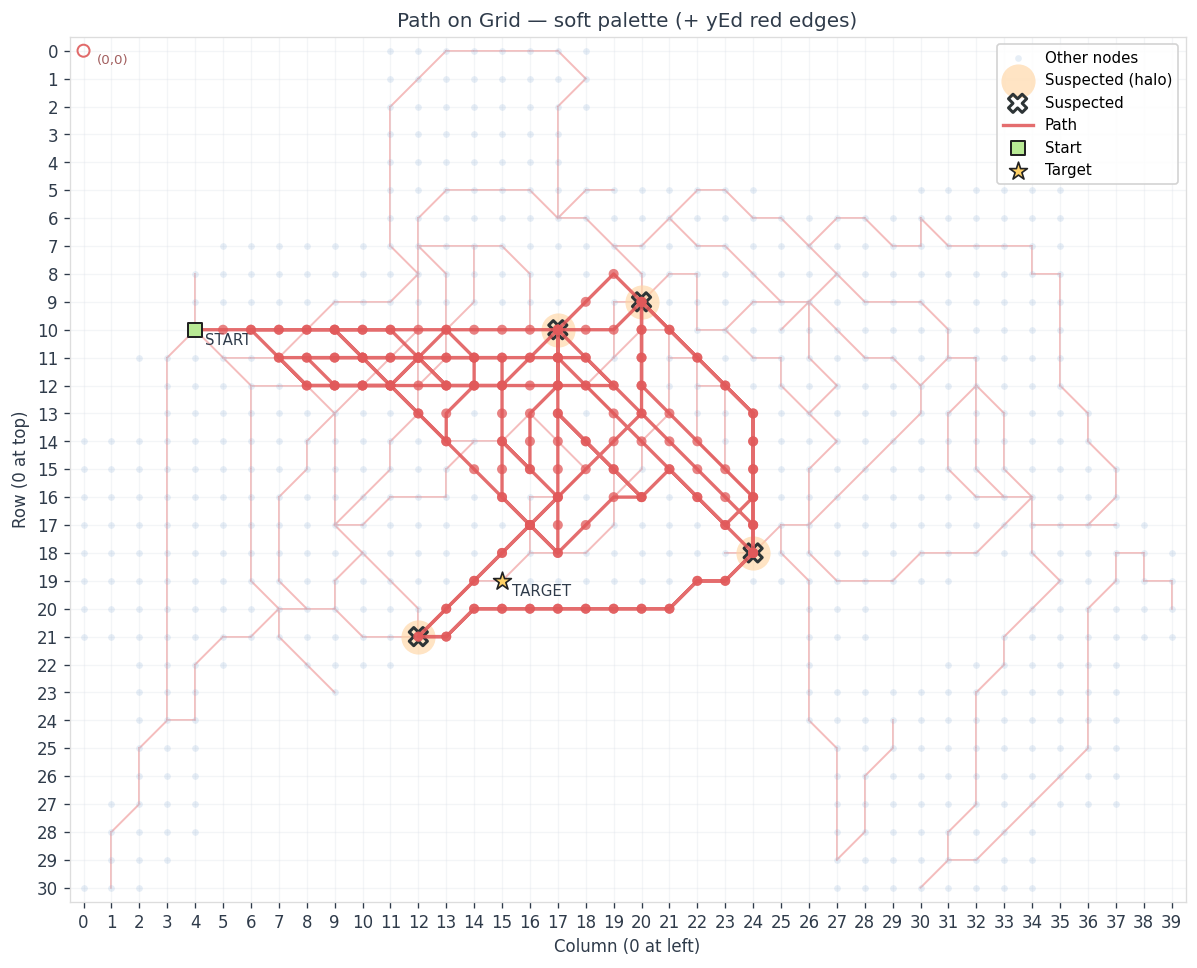

In [ ]:
print("\nStarting Saccadic Search...")

map_graph_path = "../mapGraphs/graphml/HIMCM_graph_FINAL.graphml"
#map_graph = nx.read_graphml(map_graph_path)
map_graph = load_graph_with_total_weight(map_graph_path)

start_node = "n138" 
target_node = "n239" 

#suspected_nodes = []
#suspected_nodes = ["n515"]
suspected_nodes = ["n478", "n562", "n178", "n154"]
search_path, found = saccadic_search_strategy(map_graph, start_node, max_steps, target_node, suspected_nodes=suspected_nodes)
path_taken = search_path
print("\nSearch Results:")  

if found:
    print("Target was found!")
else:
    print("Target was not found within the maximum number of steps.")
inject_node_labels_from_graphml_file(map_graph, map_graph_path, label_attr="node_label")
labeled_search_path = nodes_to_labels(map_graph, search_path, label_attr="node_label")
print("Labeled Search path:", labeled_search_path) 

# G already loaded (nx.read_graphml) and path_taken computed
fig, ax = plot_grid_path_with_red_edges(
    map_graph,
    path_taken,
    target_node=target_node,
    suspected_nodes=suspected_nodes,
    graphml_path=map_graph_path,   # let it auto-mark yEd red edges
    label_attr="node_label",
    figsize=(12,12),
    grid_alpha=0.3,
)



In [67]:
for searched_node in search_path:
    for node, data in map_graph.nodes(data=True):
        if searched_node == node:
            print(f"Node: {node}, Attributes: {data}")
            print("X:", int(float(data["x"]) / 50))
            print("Y:", int(float(data["y"]) / 50))

Node: n138, Attributes: {'x': '201.34244411651133', 'y': '573.5505850318488', 'shape_type': 'ellipse', 'label': '11,4', 'P(target)': 0.001494985607611825}
X: 4
Y: 11
Node: n131, Attributes: {'x': '248.3117094752992', 'y': '621.4321958884899', 'shape_type': 'ellipse', 'label': '12,5', 'P(target)': 0.0006644380478274785}
X: 4
Y: 12
Node: n140, Attributes: {'x': '298.1568643383582', 'y': '671.3473589934093', 'shape_type': 'ellipse', 'label': '13,6', 'P(target)': 7.382644975860873e-05}
X: 5
Y: 13
Node: n147, Attributes: {'x': '348.52692343292597', 'y': '672.0426453477386', 'shape_type': 'ellipse', 'label': '13,7', 'P(target)': 2.050734715516909e-06}
X: 6
Y: 13
Node: n149, Attributes: {'x': '393.4297248471613', 'y': '670.3824831555406', 'shape_type': 'ellipse', 'label': '13,8', 'P(target)': 2.050734715516909e-06}
X: 7
Y: 13
Node: n12, Attributes: {'x': '443.9136948765907', 'y': '718.5026128475819', 'shape_type': 'ellipse', 'label': '14,9', 'P(target)': 2.050734715516909e-06}
X: 8
Y: 14
Node

## Test Cases

### Static Test

In [68]:
start_nodes = ["n0", "n20", "n33", "n200", "n555"]
target_nodes = ["n20", "n22", "n576", "n714", "n123"]
max_steps = 213

In [69]:
def static_test(graph, start_nodes, target_nodes):
    for start_node, target_node in zip(start_nodes, target_nodes):
        print("Start Node: " + start_node, "Target Node: " + target_node)

        search_path, found = saccadic_search_strategy(graph, start_node, max_steps, target_node)
        
        inject_node_labels_from_graphml_file(graph, map_graph_path, label_attr="y:LabelModel")

        path_labels = nodes_to_labels(graph, search_path, label_attr="y:LabelModel")
        
        print("Path (labels):", " -> ".join(path_labels))
        print("Target found:", found)

In [70]:
map_graph = nx.read_graphml(map_graph_path)

static_test(map_graph, start_nodes, target_nodes)


Start Node: n0 Target Node: n20
Number of steps taken:  47
Path (labels): 16,11 -> 16,11 -> 16,10 -> 15,11 -> 16,12 -> 16,11 -> 15,10 -> 16,10 -> 17,11 -> 17,10 -> 16,11 -> 15,12 -> 16,12 -> 17,12 -> 17,12 -> 16,11 -> 15,11 -> 14,11 -> 14,12 -> 15,11 -> 14,10 -> 15,11 -> 15,11 -> 15,11 -> 15,11 -> 15,10 -> 14,9 -> 15,9 -> 16,9 -> 17,10 -> 18,11 -> 17,12 -> 16,13 -> 16,12 -> 16,11 -> 17,10 -> 17,9 -> 17,10 -> 16,11 -> 15,11 -> 14,12 -> 15,13 -> 16,13 -> 17,13 -> 17,13 -> 16,13 -> 15,14 -> 14,13
Target found: True
Start Node: n20 Target Node: n22
Number of steps taken:  54
Path (labels): 14,13 -> 14,12 -> 15,11 -> 16,11 -> 16,11 -> 15,11 -> 15,11 -> 14,12 -> 15,11 -> 16,10 -> 16,11 -> 16,12 -> 16,11 -> 15,10 -> 16,10 -> 17,11 -> 17,10 -> 16,11 -> 15,12 -> 16,12 -> 17,12 -> 16,11 -> 15,11 -> 14,11 -> 14,10 -> 14,9 -> 15,9 -> 16,9 -> 17,10 -> 18,11 -> 17,12 -> 16,13 -> 16,12 -> 16,11 -> 17,10 -> 17,9 -> 17,10 -> 16,11 -> 15,11 -> 14,12 -> 15,13 -> 15,13 -> 16,13 -> 17,13 -> 16,13 -> 15,14 

### Random Test

In [71]:
number_of_test_cases = 5
max_steps = 15000

In [72]:
def random_test(graph, number_of_test_cases):
    number_of_nodes = len(graph.nodes())
    start_nodes = []
    target_nodes = []

    for i in range(number_of_test_cases):
        start_nodes.append("n" + str(random.randint(0, number_of_nodes)))
        target_nodes.append(("n" + str(random.randint(0, number_of_nodes))))
    
    static_test(graph, start_nodes, target_nodes)

In [73]:
map_graph = nx.read_graphml(map_graph_path)

random_test(map_graph, number_of_test_cases)

Start Node: n385 Target Node: n75
Number of steps taken:  303
Path (labels): 14,34 -> 14,33 -> 13,32 -> 14,31 -> 13,30 -> 12,29 -> 12,28 -> 11,27 -> 10,26 -> 10,25 -> 10,24 -> 11,23 -> 11,22 -> 11,21 -> 11,20 -> 12,19 -> 13,18 -> 13,17 -> 14,16 -> 15,15 -> 15,14 -> 16,13 -> 16,12 -> 16,11 -> 16,12 -> 16,12 -> 16,12 -> 16,12 -> 16,13 -> 15,14 -> 15,15 -> 14,16 -> 13,17 -> 13,18 -> 12,19 -> 11,20 -> 11,21 -> 11,22 -> 11,23 -> 10,24 -> 10,25 -> 10,26 -> 11,27 -> 12,28 -> 12,29 -> 13,30 -> 12,31 -> 13,32 -> 12,31 -> 13,30 -> 12,29 -> 12,28 -> 11,27 -> 10,26 -> 10,25 -> 10,24 -> 11,23 -> 11,22 -> 11,21 -> 11,20 -> 12,19 -> 13,18 -> 13,17 -> 14,16 -> 15,15 -> 15,14 -> 15,13 -> 14,12 -> 15,11 -> 16,10 -> 15,11 -> 14,12 -> 15,13 -> 15,14 -> 15,15 -> 15,15 -> 15,15 -> 15,15 -> 15,14 -> 15,13 -> 14,12 -> 15,11 -> 15,10 -> 16,10 -> 17,11 -> 17,10 -> 17,10 -> 17,10 -> 17,10 -> 16,11 -> 15,12 -> 16,12 -> 17,12 -> 17,12 -> 16,11 -> 15,11 -> 14,11 -> 14,10 -> 14,10 -> 14,9 -> 14,9 -> 15,9 -> 16,9 -> 

# Best Bayesian Search

In [219]:
import random
from typing import Tuple, List, Dict, Any

def run_saccadic_trials(
    G,
    start_node: str,
    target_node: str,
    suspected_nodes: List[str],
    max_steps: int,
    n_trials: int = 200,
    base_seed: int = 1337,
) -> Tuple[List[str], bool, Dict[str, Any]]:
    """
    Run saccadic_search_strategy multiple times with different seeds.
    Return the shortest successful path (if any), otherwise the shortest path overall.

    stats keys:
        'n_trials', 'n_found', 'best_len_found', 'best_len_any',
        'best_found', 'best_any', 'seeds_found'
    """
    best_found_path, best_found_len, best_found_seed = None, float("inf"), None
    best_any_path,   best_any_len,   best_any_seed   = None, float("inf"),   None
    seeds_found = []

    for i in range(n_trials):
        # make each trial stochastic
        random.seed(base_seed + i)

        path, found = saccadic_search_strategy(
            G, start_node=start_node, max_steps=max_steps,
            target_node=target_node, suspected_nodes=suspected_nodes
        )
        L = len(path) if path else float("inf")

        # track best overall
        if L < best_any_len:
            best_any_len, best_any_path, best_any_seed = L, path, base_seed + i

        # track best among successful runs
        if found and L < best_found_len:
            best_found_len, best_found_path, best_found_seed = L, path, base_seed + i
            seeds_found.append(base_seed + i)

    have_success = best_found_path is not None
    chosen_path  = best_found_path if have_success else best_any_path

    stats = dict(
        n_trials=n_trials,
        n_found=len(seeds_found),
        best_len_found=(None if not have_success else best_found_len),
        best_len_any=best_any_len,
        best_found=best_found_seed,
        best_any=best_any_seed,
        seeds_found=seeds_found,
    )
    return chosen_path, have_success, stats



Starting Saccadic Search (200 trials)...
[weight-mapper] set from totals: 0, fallback sums: 0, defaults: 5236

Search Results (200 trials):
  successful runs: 4 / 200
  best successful length: 76
  best overall length: 76
  seed of chosen run: 1524
  chosen path length: 76
  chosen path nodes: ['n138', 'n126', 'n125', 'n128', 'n141', 'n113', 'n101', 'n100', 'n103', 'n116', 'n188', 'n176', 'n175', 'n178', 'n191', 'n163', 'n154', 'n151', 'n156', 'n171', 'n61', 'n64', 'n91', 'n83', 'n90', 'n518', 'n523', 'n476', 'n478', 'n478', 'n480', 'n526', 'n520', 'n519', 'n522', 'n528', 'n512', 'n507', 'n506', 'n504', 'n511', 'n562', 'n511', 'n504', 'n506', 'n507', 'n512', 'n528', 'n522', 'n519', 'n520', 'n526', 'n480', 'n478', 'n480', 'n526', 'n520', 'n519', 'n522', 'n528', 'n512', 'n507', 'n506', 'n504', 'n511', 'n562', 'n511', 'n504', 'n506', 'n507', 'n512', 'n528', 'n522', 'n519', 'n520', 'n515']
  found target? YES
[viz] Marked 660 red edge(s) from GraphML.


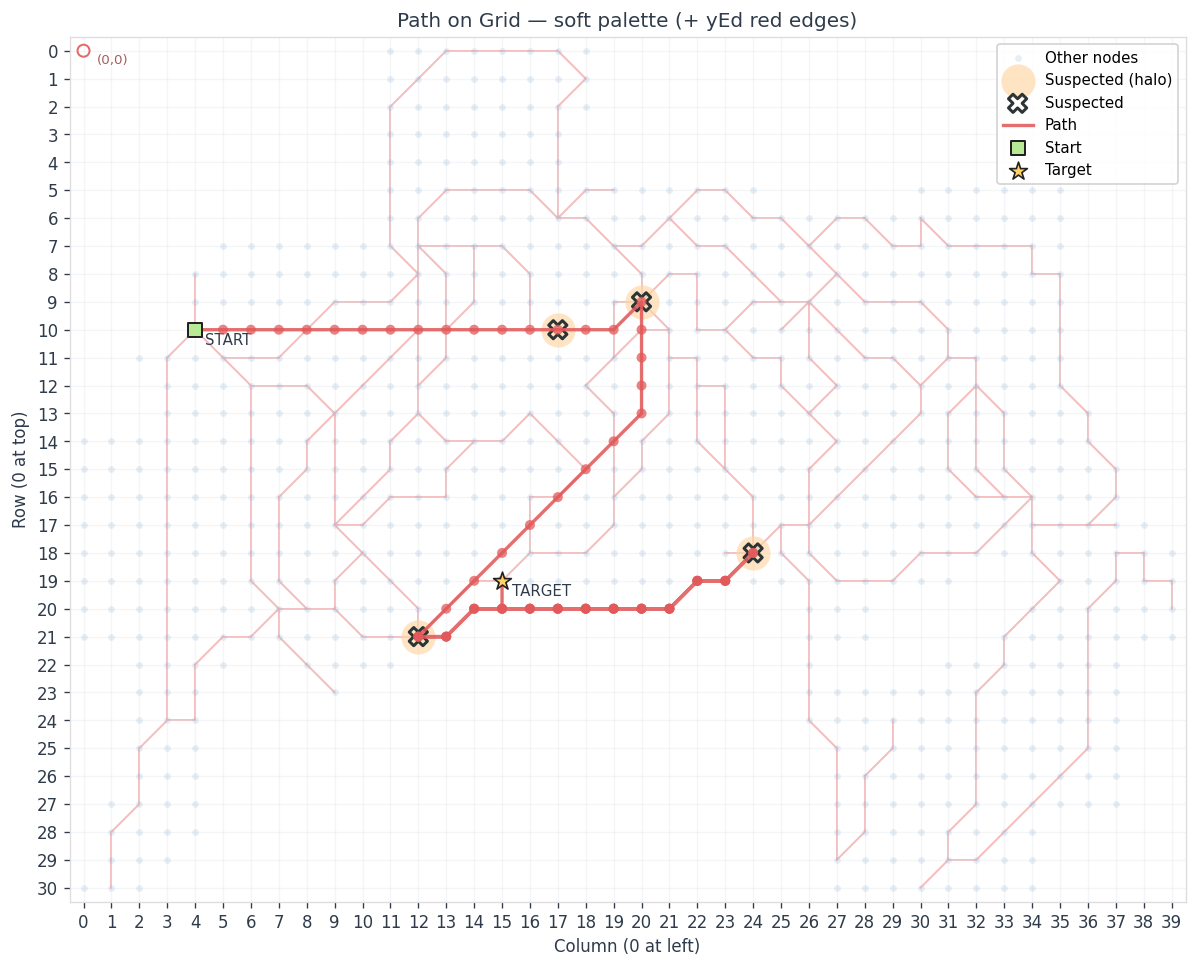

In [220]:
print("\nStarting Saccadic Search (200 trials)...")

map_graph_path = "../mapGraphs/graphml/HIMCM_graph_FINAL.graphml"
map_graph = load_graph_with_total_weight(map_graph_path)

start_node   = "n138"
target_node  = "n515"
suspected_nodes = ["n478", "n562", "n178", "n154"]
max_steps    = max_steps  # keep your existing variable

# (Optional) ensure nodes have labels like "row,col"
inject_node_labels_from_graphml_file(map_graph, map_graph_path, label_attr="node_label")

# Run many trials and pick the best
best_path, best_found, stats = run_saccadic_trials(
    map_graph, start_node, target_node, suspected_nodes, max_steps,
    n_trials=200, base_seed=1337
)

print("\nSearch Results (200 trials):")
print(f"  successful runs: {stats['n_found']} / {stats['n_trials']}")
print(f"  best successful length: {stats['best_len_found']}")
print(f"  best overall length: {stats['best_len_any']}")
print(f"  seed of chosen run: {stats['best_found'] if best_found else stats['best_any']}")
print("  chosen path length:", len(best_path))
print("  chosen path nodes:", best_path)
print("  found target?", "YES" if best_found else "NO")

# Plot only the chosen (best) path
fig, ax = plot_grid_path_with_red_edges(
    map_graph,
    best_path,
    target_node=target_node,
    suspected_nodes=suspected_nodes,
    graphml_path=map_graph_path,     # auto-mark yEd red edges
    label_attr="node_label",
    figsize=(12, 12),
    grid_alpha=0.3,
)


# Monte Carlo Simulation

In [227]:
import random, math
import networkx as nx
from typing import List, Tuple, Dict, Any

def _weighted_or_unweighted_distances(G, source, weight_key="weight"):
    """Return dict of distances from source. Uses Dijkstra if 'weight' exists on any edge; otherwise unweighted BFS."""
    use_weight = any('weight' in d for *_, d in G.edges(data=True))
    try:
        if use_weight:
            return nx.single_source_dijkstra_path_length(G, source=source, weight=weight_key)
        else:
            return nx.single_source_shortest_path_length(G, source=source)
    except nx.NetworkXError:
        return {}

def _choose_suspects_randomized(
    G,
    k: int,
    start_node: str,
    target_node: str,
    scenario: str,
    rng: random.Random,
    weight_key="weight",
    pool_factor: float = 2.5,
):
    """
    Build ONE randomized suspect set of size k for the given scenario.

    - include_target: always contains target; remaining k-1 are random from others.
    - random: k random nodes (excluding target & start).
    - near:   sample k from the top 'pool_size' nearest-to-target nodes.
    - far:    sample k from the top 'pool_size' farthest-from-target nodes.

    pool_size = max(k, ceil(k * pool_factor))
    """
    all_nodes = set(G.nodes())
    others = [n for n in all_nodes if n not in (start_node, target_node)]

    # Distances from target
    dist = _weighted_or_unweighted_distances(G, target_node, weight_key=weight_key)
    reachable = [n for n in others if n in dist]
    unreachable = [n for n in others if n not in dist]

    # Helper to pad if pool smaller than k
    def _pick_from_pool(pool: List[str], k: int) -> List[str]:
        pool = list(pool)
        rng.shuffle(pool)
        if len(pool) >= k:
            return pool[:k]
        # pad from remaining (others not in pool)
        remaining = [n for n in others if n not in pool]
        rng.shuffle(remaining)
        need = k - len(pool)
        return pool + remaining[:need]

    if scenario == "include_target":
        pool = list(others)
        rng.shuffle(pool)
        return [target_node] + pool[:max(0, k - 1)]

    if scenario == "random":
        pool = list(others)
        rng.shuffle(pool)
        return pool[:k]

    # For near/far, build a pool by distance, then sample k from that pool
    pool_size = max(k, int(math.ceil(k * pool_factor)))

    if scenario == "near":
        near_sorted = sorted(reachable, key=lambda n: dist[n])
        pool = near_sorted[:pool_size]
        if len(pool) < k and unreachable:
            # allow padding with unreachable to reach k
            extra = [n for n in unreachable if n not in pool]
            pool = pool + extra
        return _pick_from_pool(pool, k)

    if scenario == "far":
        far_sorted = sorted(reachable, key=lambda n: dist[n], reverse=True)
        pool = far_sorted[:pool_size]
        if len(pool) < k and unreachable:
            extra = [n for n in unreachable if n not in pool]
            pool = pool + extra
        return _pick_from_pool(pool, k)

    raise ValueError(f"Unknown scenario: {scenario}")

def run_saccadic_trials(
    G,
    start_node: str,
    target_node: str,
    suspected_nodes: list,
    max_steps: int,
    n_trials: int = 50,
    base_seed: int = 1337,
):
    """
    Run n_trials with different seeds.
    Return the shortest successful path (if any), else the shortest path overall.
    Also report how many trials succeeded (n_found).
    """
    best_found_path, best_found_len, best_found_seed = None, float("inf"), None
    best_any_path,   best_any_len,   best_any_seed   = None, float("inf"),   None

    n_found = 0
    seeds_found = []

    for i in range(n_trials):
        random.seed(base_seed + i)
        path, found = saccadic_search_strategy(
            G,
            start_node=start_node,
            max_steps=max_steps,
            target_node=target_node,
            suspected_nodes=suspected_nodes
        )
        L = len(path) if path else float("inf")

        if L < best_any_len:
            best_any_len, best_any_path, best_any_seed = L, path, base_seed + i

        if found:
            n_found += 1
            seeds_found.append(base_seed + i)
            if L < best_found_len:
                best_found_len, best_found_path, best_found_seed = L, path, base_seed + i

    have_success = best_found_path is not None
    chosen_path  = best_found_path if have_success else best_any_path

    stats = dict(
        n_trials=n_trials,
        n_found=n_found,                     # successes across trials IN THIS CONFIG
        best_len_found=(None if not have_success else best_found_len),
        best_len_any=best_any_len,
        best_found=best_found_seed,
        best_any=best_any_seed,
        seeds_found=seeds_found,
    )
    return chosen_path, have_success, stats

def monte_carlo_saccadic_sweep(
    G,
    start_node: str,
    target_node: str,
    max_steps: int,
    *,
    ks=range(1, 8),
    scenarios=("include_target", "near", "far", "random"),
    trials_per_config=50,
    configs_per_scenario=10,
    base_seed=2025,
    weight_key="weight",
    pool_factor=2.5,
):
    """
    For each k and scenario:
      - Sample 'configs_per_scenario' suspect sets (configurations).
      - For each configuration, run run_saccadic_trials once (n_trials trials) and keep its BEST trial as the representative.
      - 'p_found' for (k, scenario) = fraction of configurations that had at least one success.

    Returns:
      rows: one summary dict PER (k, scenario) containing:
            - p_found_configs (our new probability-of-solvability)
            - best_config_row (the single best configuration among the sampled ones)
      best_overall: the best configuration across all k & scenarios (by success then shortest path).
    """
    rows = []
    all_config_rows = []  # keep every config’s representative for global best picking

    for k in ks:
        for s_idx, scenario in enumerate(scenarios):
            rng_base = base_seed + 100_000*k + 1000*s_idx

            config_rows = []
            n_configs_found = 0

            for cfg in range(configs_per_scenario):
                rng = random.Random(rng_base + cfg)

                suspects = _choose_suspects_randomized(
                    G, k, start_node, target_node, scenario,
                    rng=rng, weight_key=weight_key, pool_factor=pool_factor
                )

                best_path, have_success, stats = run_saccadic_trials(
                    G,
                    start_node=start_node,
                    target_node=target_node,
                    suspected_nodes=suspects,
                    max_steps=max_steps,
                    n_trials=trials_per_config,
                    base_seed=base_seed + 10_000*k + 123*(s_idx+1) + cfg,
                )

                if have_success:
                    n_configs_found += 1

                # This row represents the CONFIGURATION (best trial already chosen inside)
                cfg_row = dict(
                    k=k,
                    scenario=scenario,
                    suspects=suspects,
                    have_success=have_success,
                    best_path=best_path,
                    best_len_found=stats["best_len_found"],  # may be None if no success
                    best_len_any=stats["best_len_any"],
                    n_trials=trials_per_config,
                    n_found=stats["n_found"],                 # successes within this config’s trials
                    config_index=cfg,
                )
                config_rows.append(cfg_row)
                all_config_rows.append(cfg_row)

            # Probability that a randomly sampled configuration is solvable:
            p_found_configs = n_configs_found / float(configs_per_scenario)

            # Pick the single BEST config for this (k, scenario):
            # priority: have_success=True, then min best_len_found, then min best_len_any, then smaller config_index
            def _score_cfg(ent):
                blf = ent["best_len_found"] if ent["best_len_found"] is not None else float("inf")
                return (0 if ent["have_success"] else 1, blf, ent["best_len_any"], ent["config_index"])

            best_config_row = sorted(config_rows, key=_score_cfg)[0]

            rows.append(dict(
                k=k,
                scenario=scenario,
                p_found=p_found_configs,         # <-- NEW definition: across CONFIGS
                n_configs=configs_per_scenario,
                n_configs_found=n_configs_found,
                best_config=best_config_row,     # representative config to plot for this (k,scenario)
            ))

            print(f"[k={k:>2} | {scenario:14}] "
                  f"p_found_configs={p_found_configs:.3f}  "
                  f"best_len_found={best_config_row['best_len_found']}  "
                  f"best_len_any={best_config_row['best_len_any']}  "
                  f"config={best_config_row['config_index']}  "
                  f"suspects={len(best_config_row['suspects'])}")

    # Global best configuration across everything
    def _score_overall(ent):
        blf = ent["best_len_found"] if ent["best_len_found"] is not None else float("inf")
        return (0 if ent["have_success"] else 1, blf, ent["best_len_any"], ent["k"], ent["scenario"], ent["config_index"])

    best_overall = sorted(all_config_rows, key=_score_overall)[0]

    print("\n=== Best overall configuration (across all k & scenarios) ===")
    print(f"k={best_overall['k']}  scenario={best_overall['scenario']}  "
          f"have_success={best_overall['have_success']}  "
          f"best_len_found={best_overall['best_len_found']}  best_len_any={best_overall['best_len_any']}")
    print("suspects:", best_overall["suspects"])
    print("chosen path length:", len(best_overall["best_path"]))

    return rows, best_overall



In [234]:
# same start/target/max_steps as before
map_graph_path = "../mapGraphs/graphml/HIMCM_graph_FINAL.graphml"
map_graph = nx.read_graphml(map_graph_path)
#map_graph = load_graph_with_total_weight(map_graph_path)

start_node = "n138" 
target_node = "n239" 
rows, best = monte_carlo_saccadic_sweep(
    map_graph,
    start_node=start_node,
    target_node=target_node,
    max_steps=213,
    ks=range(1, 8),
    scenarios=("include_target", "near", "far", "random"),
    trials_per_config=5,         # same as before
    configs_per_scenario=100,      # <-- NEW: 10 random suspect sets per (k, scenario)
    base_seed=2025,
    pool_factor=2.5,              # broaden/ tighten near/far pools (2.0–4.0 is reasonable)
)

# Plot only the overall best
fig, ax = plot_grid_path_with_red_edges(
    map_graph,
    best["best_path"],
    target_node="n239",
    suspected_nodes=best["suspects"],
    graphml_path=map_graph_path,
    label_attr="node_label",
    figsize=(12, 12),
    grid_alpha=0.25,
)


[k= 1 | include_target] p_found_configs=1.000  best_len_found=27  best_len_any=27  config=0  suspects=1
[k= 1 | near          ] p_found_configs=0.000  best_len_found=None  best_len_any=214  config=0  suspects=1
[k= 1 | far           ] p_found_configs=0.000  best_len_found=None  best_len_any=214  config=0  suspects=1
[k= 1 | random        ] p_found_configs=0.000  best_len_found=None  best_len_any=214  config=0  suspects=1
[k= 2 | include_target] p_found_configs=1.000  best_len_found=27  best_len_any=27  config=0  suspects=2
[k= 2 | near          ] p_found_configs=0.400  best_len_found=27  best_len_any=27  config=3  suspects=2
[k= 2 | far           ] p_found_configs=0.000  best_len_found=None  best_len_any=214  config=0  suspects=2
[k= 2 | random        ] p_found_configs=0.010  best_len_found=30  best_len_any=30  config=90  suspects=2
[k= 3 | include_target] p_found_configs=1.000  best_len_found=27  best_len_any=27  config=0  suspects=3
[k= 3 | near          ] p_found_configs=0.920  best

ValueError: Node 'n138' has no (row,col) info.